In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

# Pandas is used for reading, cleaning and manipulating data
import pandas as pd

# NumPy is used for numerical calculations
import numpy as np

# Matplotlib is used for creating visualizations
import matplotlib.pyplot as plt

# Seaborn is used for statistical visualizations
import seaborn as sns

# Used to split data into training and validation sets
from sklearn.model_selection import train_test_split

# Used to standardize numerical values
from sklearn.preprocessing import StandardScaler

# Machine learning evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Random Forest algorithm
from sklearn.ensemble import RandomForestClassifier

# XGBoost algorithm
from xgboost import XGBClassifier

# Joblib is used to save the trained model
import joblib

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Set the default visualization style
sns.set_theme(style="whitegrid")


In [2]:
train = pd.read_csv(r"\Users\raiis\Downloads\aug_train.csv")
test = pd.read_csv(r"\Users\raiis\Downloads\aug_test.csv")
print("Training data shape:", train.shape)
print("Test data shape:", test.shape)

Training data shape: (19158, 14)
Test data shape: (2129, 13)


In [3]:
train.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
test.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [5]:
# Display information about columns, data types and missing values
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [7]:
# Count missing values in each column
missing_count = train.isnull().sum()

# Calculate missing-value percentage
missing_percentage = (
    missing_count / len(train)
) * 100

# Create a DataFrame containing missing-value information
missing_df = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage": missing_percentage
})

# Sort from highest to lowest missing percentage
missing_df = missing_df.sort_values(
    "Percentage",
    ascending=False
)

# Display missing-value summary
missing_df

,Missing Values,Percentage
company_type,6140,32.049274
company_size,5938,30.994885
gender,4508,23.530640
major_discipline,2813,14.683161
education_level,460,2.401086
last_new_job,423,2.207955
enrolled_university,386,2.014824
experience,65,0.339284
enrollee_id,0,0.000000
city,0,0.000000


In [8]:
# Count duplicate rows
duplicate_count = train.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicate_count
)

Number of duplicate rows: 0


In [9]:
# Count employees in each target class
print(
    train["target"].value_counts()
)

target
0.0    14381
1.0     4777
Name: count, dtype: int64


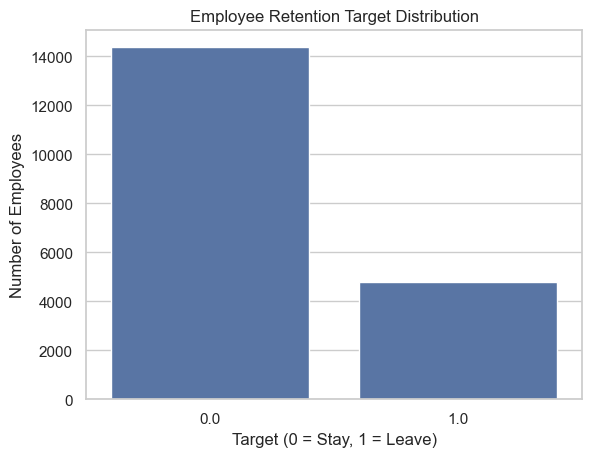

In [10]:
# Create a count plot of the target variable
sns.countplot(
    data=train,
    x="target"
)

# Add title
plt.title(
    "Employee Retention Target Distribution"
)

# Label x-axis
plt.xlabel(
    "Target (0 = Stay, 1 = Leave)"
)

# Label y-axis
plt.ylabel(
    "Number of Employees"
)

# Display the graph
plt.show()

In [11]:
# Find columns containing categorical/text data
categorical_columns = train.select_dtypes(
    include="object"
).columns.tolist()

# Display categorical columns
print(categorical_columns)

['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


In [12]:
train.dropna(inplace = True)
test.dropna(inplace= True)

In [13]:
# Check whether training data still contains missing values
print("Training missing values:")
print(train.isnull().sum())

Training missing values:
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64


In [14]:
# Check whether test data still contains missing values
print("Test missing values:")
print(test.isnull().sum())

Test missing values:
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64


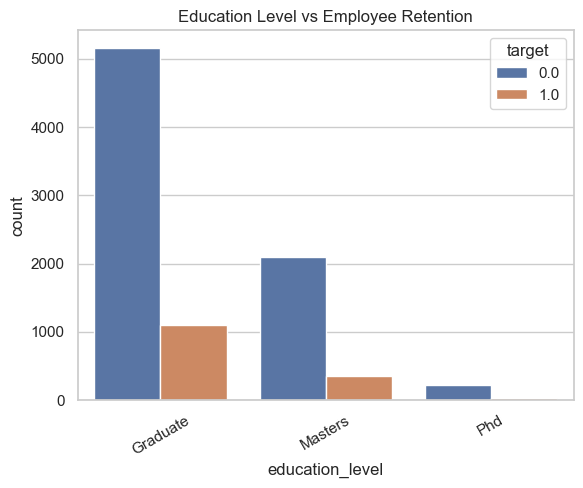

In [15]:
# Compare education level with employee retention
sns.countplot(
    data=train,
    x="education_level",
    hue="target"
)

# Add title
plt.title(
    "Education Level vs Employee Retention"
)

# Rotate x-axis labels
plt.xticks(rotation=30)

# Display graph
plt.show()

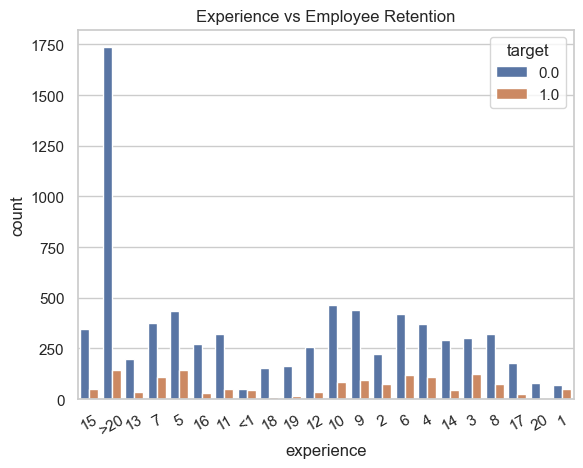

In [16]:
# Compare experience with employee retention
sns.countplot(
    data=train,
    x="experience",
    hue="target"
)

# Add title
plt.title(
    "Experience vs Employee Retention"
)

# Rotate labels
plt.xticks(rotation=30)

# Display graph
plt.show()

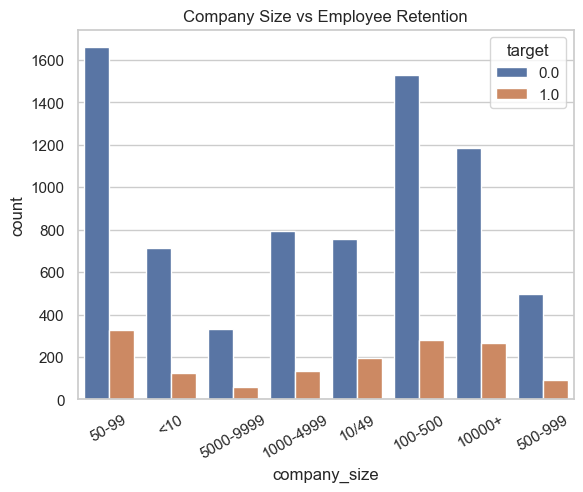

In [17]:
# Compare company size with employee retention
sns.countplot(
    data=train,
    x="company_size",
    hue="target"
)

# Add title
plt.title(
    "Company Size vs Employee Retention"
)

# Rotate labels
plt.xticks(rotation=30)

# Display graph
plt.show()

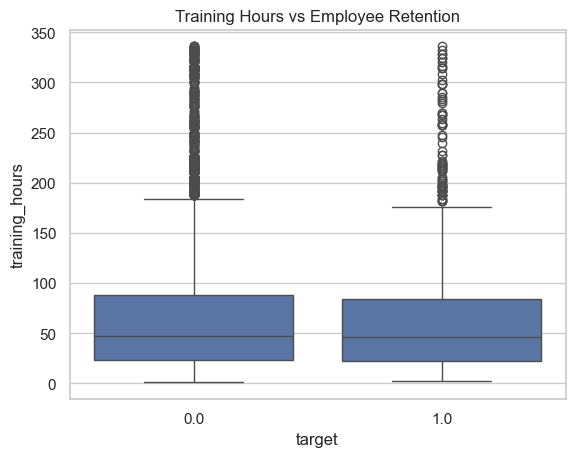

In [18]:
# Compare training hours for employees who stay and leave
sns.boxplot(
    data=train,
    x="target",
    y="training_hours"
)

# Add title
plt.title(
    "Training Hours vs Employee Retention"
)

# Display graph
plt.show()

In [19]:
# Save employee IDs from the test dataset
test_ids = test["enrollee_id"].copy()

In [20]:
# Create X containing all input features
X = train.drop(
    columns=["target"]
)

# Create y containing the target variable
y = train["target"]

# Display their shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8955, 13)
y shape: (8955,)


In [21]:
# Remove employee ID because it is only an identifier
X = X.drop(
    columns=["enrollee_id"]
)

# Remove employee ID from test data as well
test_model = test.drop(
    columns=["enrollee_id"]
)

# Display the new shape
print("X shape after removing ID:", X.shape)

X shape after removing ID: (8955, 12)


In [93]:
# ============================================================
# ONE-HOT ENCODING
# ============================================================

# Convert categorical columns into numerical columns
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

# Apply the same encoding to test data
test_encoded = pd.get_dummies(
    test_model,
    drop_first=True
)

# Make test columns exactly match training columns
test_encoded = test_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

# Display shapes
print("Encoded training data:", X_encoded.shape)
print("Encoded test data:", test_encoded.shape)

Encoded training data: (8955, 167)
Encoded test data: (1019, 167)


In [94]:
# ============================================================
# FIX FEATURE NAMES FOR XGBOOST
# ============================================================

# Convert all feature names to strings
X_encoded.columns = X_encoded.columns.astype(str)

# Replace characters that XGBoost does not allow
X_encoded.columns = (
    X_encoded.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

# Apply exactly the same cleaning to test columns
test_encoded.columns = test_encoded.columns.astype(str)

test_encoded.columns = (
    test_encoded.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

# Make test columns exactly match training columns
test_encoded = test_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

print("Feature names fixed successfully!")

Feature names fixed successfully!


In [95]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

Training data: (7164, 167)
Validation data: (1791, 167)


In [96]:
# ============================================================
# RANDOM FOREST
# ============================================================

# Create Random Forest model
rf_model = RandomForestClassifier(
    # Number of trees
    n_estimators=300,

    # Make results reproducible
    random_state=42,

    # Handle class imbalance
    class_weight="balanced",
)

# Train Random Forest
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [133]:
# ============================================================
# RANDOM FOREST PREDICTION
# ============================================================

# Predict class labels
rf_pred = rf_model.predict(
    X_val
)

# Get probability of class 1
# This probability is required for ROC-AUC
rf_probability = rf_model.predict_proba(
    X_val
)[:, 1]

In [134]:
# Calculate Random Forest accuracy
rf_accuracy = accuracy_score(
    y_val,
    rf_pred
)

# Calculate precision
rf_precision = precision_score(
    y_val,
    rf_pred,
    zero_division=0
)

# Calculate recall
rf_recall = recall_score(
    y_val,
    rf_pred,
    zero_division=0
)

# Calculate F1 score
rf_f1 = f1_score(
    y_val,
    rf_pred,
    zero_division=0
)

# Calculate ROC-AUC
rf_auc = roc_auc_score(
    y_val,
    rf_prob
)

# Display results
print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.8509
Precision: 0.5728
Recall   : 0.3973
F1 Score : 0.4692
ROC-AUC  : 0.7556


In [135]:
# ============================================================
# CALCULATE CLASS IMBALANCE
# ============================================================

# Count class 0
class_0 = (
    y_train == 0
).sum()

# Count class 1
class_1 = (
    y_train == 1
).sum()

# Calculate ratio
scale_pos_weight = (
    class_0 / class_1
)

# Display values
print("Class 0:", class_0)
print("Class 1:", class_1)
print(
    "Scale Pos Weight:",
    scale_pos_weight
)

Class 0: 5978
Class 1: 1186
Scale Pos Weight: 5.040472175379427


In [99]:
# ============================================================
# XGBOOST
# ============================================================

# Create XGBoost classifier
xgb_model = XGBClassifier(
    
    # Number of boosting trees
    n_estimators=300,
    
    # Maximum depth of each tree
    max_depth=5,
    
    # Percentage of features used by each tree
    colsample_bytree=0.8,
    
    # Handle class imbalance
    scale_pos_weight=scale_pos_weight,
    
    
    # Reproducibility
    random_state=42,
    
)

# Train XGBoost
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

XGBoost training completed!


In [136]:
# ============================================================
# XGBOOST PREDICTION
# ============================================================

# Predict class labels
xgb_pred = xgb_model.predict(
    X_val
)

# Get probability of class 1
# Required for ROC-AUC calculation
xgb_probability = xgb_model.predict_proba(
    X_val
)[:, 1]

In [137]:
# ============================================================
# XGBOOST EVALUATION
# ============================================================

# Calculate accuracy
xgb_accuracy = accuracy_score(
    y_val,
    xgb_pred
)

# Calculate precision
xgb_precision = precision_score(
    y_val,
    xgb_pred,
    zero_division=0
)

# Calculate recall
xgb_recall = recall_score(
    y_val,
    xgb_pred,
    zero_division=0
)

# Calculate F1 score
xgb_f1 = f1_score(
    y_val,
    xgb_pred,
    zero_division=0
)

# Calculate ROC-AUC
rf_auc = roc_auc_score(
    y_val,
    rf_prob
)

# Display results
print("XGBoost Results")
print("----------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

XGBoost Results
----------------
Accuracy : 0.8135
Precision: 0.4476
Recall   : 0.532
F1 Score : 0.4862
ROC-AUC  : 0.7556


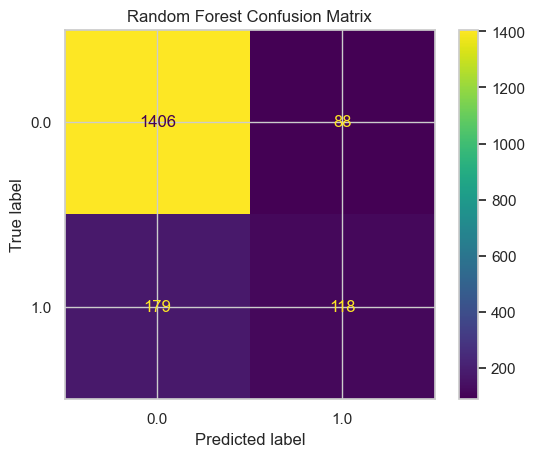

In [138]:
# Create Random Forest confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val,
    rf_pred
)

# Add title
plt.title(
    "Random Forest Confusion Matrix"
)

# Display graph
plt.show()

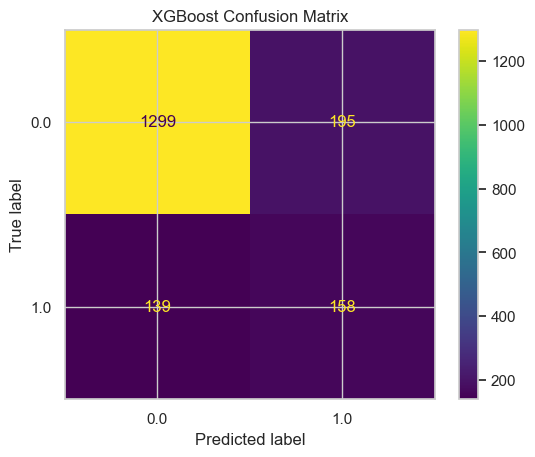

In [139]:
# Create XGBoost confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_pred
)

# Add title
plt.title(
    "XGBoost Confusion Matrix"
)

# Display graph
plt.show()

In [140]:
# Display detailed Random Forest classification report
print(
    classification_report(
        y_val,
        rf_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91      1494
         1.0       0.57      0.40      0.47       297

    accuracy                           0.85      1791
   macro avg       0.73      0.67      0.69      1791
weighted avg       0.83      0.85      0.84      1791



In [141]:
# Display detailed XGBoost classification report
print(
    classification_report(
        y_val,
        xgb_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         0.0       0.90      0.87      0.89      1494
         1.0       0.45      0.53      0.49       297

    accuracy                           0.81      1791
   macro avg       0.68      0.70      0.69      1791
weighted avg       0.83      0.81      0.82      1791



In [142]:
# ============================================================
# FINAL XGBOOST MODEL
# ============================================================

# Create final XGBoost model
final_model = XGBClassifier(
    
    # Number of trees
    n_estimators=300,
    
    # Maximum tree depth
    max_depth=5,
    
    # Learning rate
    learning_rate=0.05,
    

    # Handle class imbalance
    scale_pos_weight=(
        (y == 0).sum() /
        (y == 1).sum()
    ),
    
    
    
    # Reproducibility
    random_state=42,
    
)

# Train final model using all training data
final_model.fit(
    X_encoded,
    y
)

print(
    "Final XGBoost model trained successfully!"
)

Final XGBoost model trained successfully!


In [143]:
# ============================================================
# MODEL RESULTS
# ============================================================

# Create a DataFrame comparing both algorithms
model_results = pd.DataFrame({

    # Model names
    "Model": [
        "Random Forest",
        "XGBoost"
    ],

    # Accuracy
    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],

    # Precision
    "Precision": [
        rf_precision,
        xgb_precision
    ],

    # Recall
    "Recall": [
        rf_recall,
        xgb_recall
    ],

    # F1 score
    "F1 Score": [
        rf_f1,
        xgb_f1
    ],

    # ROC-AUC
    "ROC-AUC": [
        rf_auc,
        xgb_auc
    ]
})

# Display results
model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8509,0.5728,0.3973,0.4692,0.7556
1,XGBoost,0.8135,0.4476,0.5320,0.4862,0.7486


In [144]:
# ============================================================
#  PREDICT TEST DATA
# ============================================================

# Predict whether employees are likely to leave
test_predictions = final_model.predict(
    test_encoded
)

# Calculate probability of leaving
test_probabilities = final_model.predict_proba(
    test_encoded
)[:, 1]

# Display first 10 predictions
print(
    "Predictions:",
    test_predictions[:10]
)

# Display first 10 probabilities
print(
    "Probabilities:",
    test_probabilities[:10]
)

Predictions: [0 0 0 1 1 0 1 0 0 1]
Probabilities: [0.24395141 0.2795532  0.20226192 0.5399114  0.87498236 0.2260033
 0.8618312  0.12899368 0.2385947  0.8942184 ]


In [145]:
# ============================================================
# CREATE PREDICTION TABLE
# ============================================================

# Create DataFrame containing predictions
test_results = pd.DataFrame({

    # Employee ID
    "enrollee_id": test_ids,

    # Predicted target
    "target": test_predictions.astype(int),

    # Probability of leaving
    "leave_probability": test_probabilities
})

# Convert probability into percentage
test_results["leave_probability"] = (
    test_results["leave_probability"] * 100
)

# Convert target into readable status
test_results["status"] = (
    test_results["target"]
    .map({
        0: "Stay",
        1: "Leave"
    })
)

# Display first 10 predictions
test_results.head(10)

,enrollee_id,target,leave_probability,status
3,27385,0,24.395142,Stay
4,27724,0,27.955320,Stay
11,9272,0,20.226192,Stay
12,14249,1,53.991138,Leave
16,7865,1,87.498238,Leave
17,7463,0,22.600330,Stay
22,25202,1,86.183121,Leave
24,23570,0,12.899367,Stay
26,9548,0,23.859470,Stay
33,17189,1,89.421837,Leave


In [146]:
# ============================================================
# SAVE PREDICTIONS
# ============================================================

# Save predictions as CSV
test_results.to_csv(
    "employee_retention_predictions.csv",
    index=False
)

print(
    "Predictions saved successfully!"
)

Predictions saved successfully!


In [147]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

# Save XGBoost model
joblib.dump(
    final_model,
    "employee_retention_xgboost_model.pkl"
)

print(
    "Final model saved successfully!"
)

Final model saved successfully!


In [148]:
# ============================================================
# SAVE FEATURE COLUMNS
# ============================================================

# Save the exact feature names used by the model
joblib.dump(
    list(X_encoded.columns),
    "feature_columns.pkl"
)

print(
    "Feature columns saved successfully!"
)

Feature columns saved successfully!
